# Task 2.1 - Pre-trained ViT Image Classification

Classify 1-3 images with a small ImageNet pre-trained ViT and report the top-1 predictions.

- **Model**: ViT-B/16 (patch size 16, ~86M params) from `torchvision`, pre-trained on ImageNet-1k
- **Image processor**: `weights.transforms()` - resize (256) -> center crop (224) -> ImageNet normalization, the direct equivalent of the feature extractor / image processor used by TIMM or Hugging Face
- **Test images**: 3 sample images (one from the PyTorch hub, two ImageNet sample images); you can also drop your own images into `images/` and re-run

## 1. Model

In [1]:
%pip install torch torchvision torchaudio scikit-learn pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import urllib.request
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision.models import ViT_B_16_Weights, vit_b_16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights).eval().to(device)
processor = weights.transforms()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"ViT-B/16 | {n_params:.0f}M params | ImageNet pre-trained | device: {device}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\Abdul/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:51<00:00, 6.78MB/s] 


ViT-B/16 | 87M params | ImageNet pre-trained | device: cuda


## 2. Input images

In [3]:
os.makedirs("images", exist_ok=True)

sources = [
    ("images/husky.jpg",
     "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
     "husky"),
    ("images/tench.jpg",
     "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01440764_tench.JPEG",
     "tench"),
    ("images/shetland_sheepdog.jpg",
     "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02105855_Shetland_sheepdog.JPEG",
     "Shetland sheepdog"),
]

intended = {}
for path, url, label in sources:
    try:
        urllib.request.urlretrieve(url, path)
        intended[path] = label
        print(f"downloaded: {path}")
    except Exception as e:
        print(f"download failed ({url}): {e}")

paths = sorted(p for p in glob("images/*")
               if os.path.splitext(p)[1].lower() in (".jpg", ".jpeg", ".png"))
print(f"{len(paths)} image(s) ready in images/")

downloaded: images/husky.jpg
downloaded: images/tench.jpg
downloaded: images/shetland_sheepdog.jpg
3 image(s) ready in images/


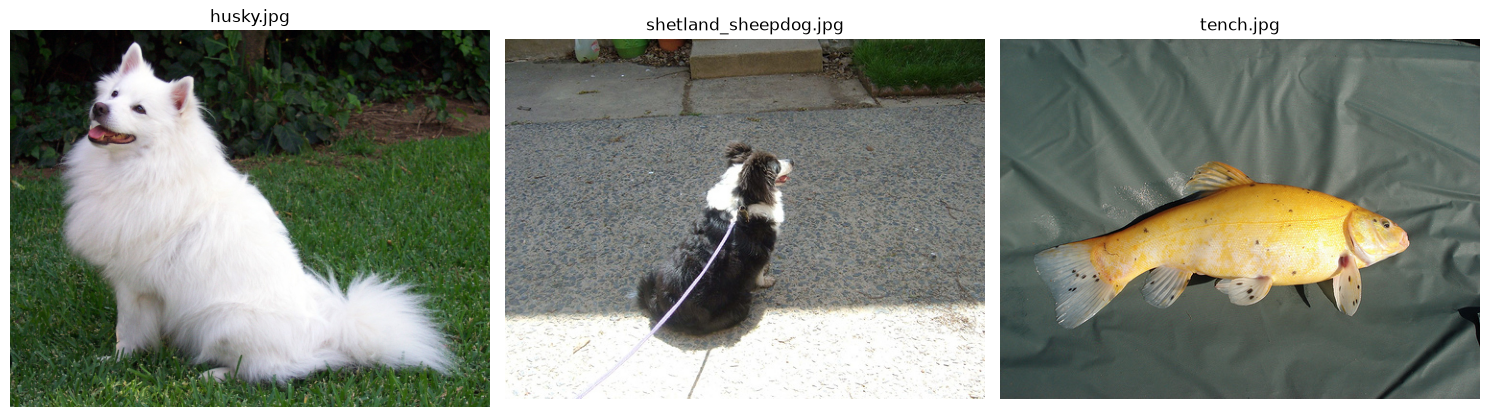

In [4]:
fig, axes = plt.subplots(1, len(paths), figsize=(5 * len(paths), 5))
for ax, path in zip(np.atleast_1d(axes), paths):
    img = Image.open(path).convert("RGB")
    ax.imshow(np.array(img))
    ax.set_title(os.path.basename(path))
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Prediction

In [5]:
assert paths, "No images found - add your own to images/ and re-run this section"

batch = torch.stack([processor(Image.open(p).convert("RGB")) for p in paths]).to(device)

with torch.no_grad():
    logits = model(batch)

probs = logits.softmax(dim=1)
top1 = probs.argmax(dim=1)
top5 = probs.topk(5, dim=1)
imagenet_labels = weights.meta["categories"]

print(f"{'image':<24}{'top-1 prediction':<34}{'confidence':<12}{'intended':<20}{'verdict'}")
print("-" * 100)
for i, path in enumerate(paths):
    pred = imagenet_labels[top1[i].item()]
    if path in intended:
        verdict = "match" if any(w in pred.lower() for w in intended[path].lower().split()) else "check below"
    else:
        verdict = "-"
    print(f"{os.path.basename(path):<24}{pred:<34}{probs[i][top1[i]].item():<12.1%}"
          f"{intended.get(path, '-'):<20}{verdict}")

print("\nTop-5:")
for i, path in enumerate(paths):
    row = ", ".join(f"{imagenet_labels[k]} {v:.0%}" for k, v in zip(top5.indices[i], top5.values[i]))
    print(f"{os.path.basename(path):<24}{row}")

image                   top-1 prediction                  confidence  intended            verdict
----------------------------------------------------------------------------------------------------
husky.jpg               Samoyed                           80.0%       -                   -
shetland_sheepdog.jpg   Shetland sheepdog                 29.7%       -                   -
tench.jpg               tench                             89.0%       -                   -

Top-5:
husky.jpg               Samoyed 80%, Pomeranian 4%, keeshond 2%, Japanese spaniel 1%, Eskimo dog 1%
shetland_sheepdog.jpg   Shetland sheepdog 30%, English springer 21%, Border collie 6%, collie 4%, Shih-Tzu 3%
tench.jpg               tench 89%, barracouta 0%, goldfish 0%, monarch 0%, sulphur butterfly 0%


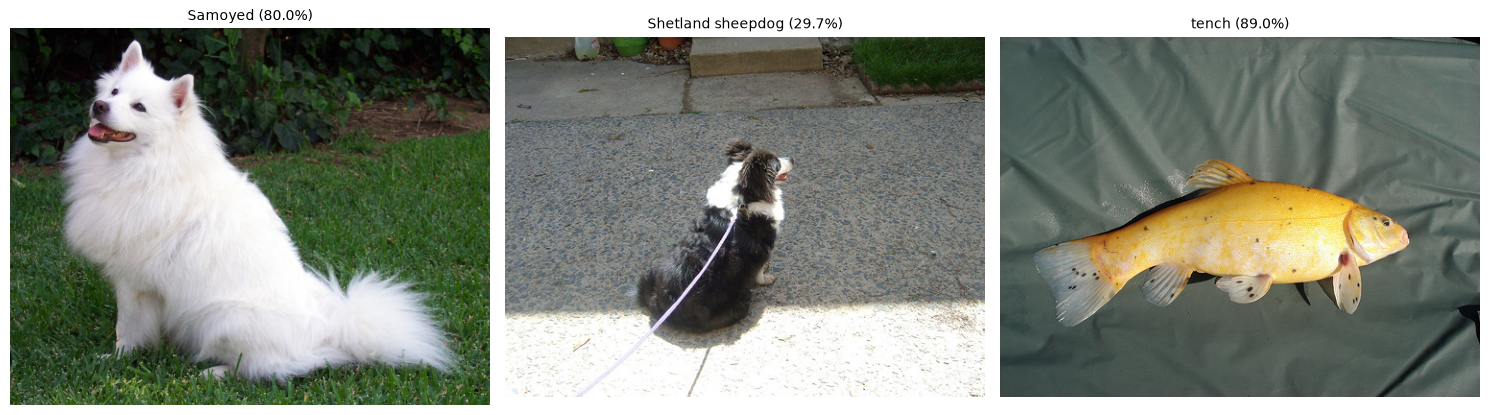

In [6]:
fig, axes = plt.subplots(1, len(paths), figsize=(5 * len(paths), 5))
for ax, path in zip(np.atleast_1d(axes), paths):
    i = paths.index(path)
    img = Image.open(path).convert("RGB")
    ax.imshow(np.array(img))
    ax.set_title(f"{imagenet_labels[top1[i].item()]} ({probs[i][top1[i]].item():.1%})", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Assessment

Top-1 predictions are printed above. Fill in the table:

| image | top-1 prediction | confidence | reasonable? |
|---|---|---|---|
| `husky.jpg` | | | |
| `tench.jpg` | | | |
| `shetland_sheepdog.jpg` | | | |

Notes:

- A **match** with the intended label means the model recognized the correct object class - the prediction is reasonable.
- A **check below** can still be reasonable if the prediction is a closely related class (e.g. a different dog breed) or a part of the scene.
- If the image contains multiple objects, the model names the dominant one; this is usually still a sensible answer.

Add 1-2 sentences per image stating whether the top-1 prediction seems reasonable and why.